<a href="https://colab.research.google.com/github/gabrielhierro/LinguagensDeProgramacao/blob/main/ExercicioPraticoMatplotlib/Atividade_Pratica_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Configuração do Ambiente e Dados Iniciais

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Gerando dados sintéticos estruturados
np.random.seed(42)
n_registros = 120

datas = pd.date_range(start='2024-01-01', periods=n_registros, freq='D')
categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
    'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)


In [7]:
print('Dados carregados:', df.shape)

# Agregações prontas para os gráficos, adaptado para o df sintético
vendas_mensal = df.set_index('data')['valor'].resample('ME').sum()
vendas_categoria = df.groupby('categoria')['valor'].sum().sort_values()
vendas_regiao = df.groupby('estado')['valor'].sum() # Usando 'estado' como proxy para 'regiao'


Dados carregados: (120, 6)


### Tarefa 1. MÓDULO 1 — Nível Básico
## Criação dos Gráficos Essenciais

---
## 1.1 Construindo Gráficos

### `plt.plot()` — Gráfico de Linha

Conecta pontos com linhas. Ideal para **séries temporais** e tendências.

**Sintaxe:** `plt.plot(x, y, format_string)`

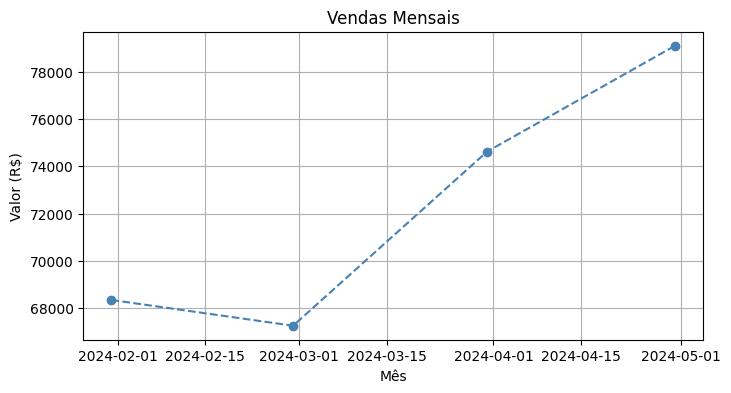

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(vendas_mensal.index, vendas_mensal.values, marker='o', linestyle='--', color='steelblue')
plt.title('Vendas Mensais')
plt.xlabel('Mês')
plt.ylabel('Valor (R$)')
plt.grid(True)
plt.show()

### `plt.bar()` — Gráfico de Barras

Compara categorias por meio de barras. Use `barh` para barras horizontais.

**Sintaxe:** `plt.bar(labels, valores, color=cor)`

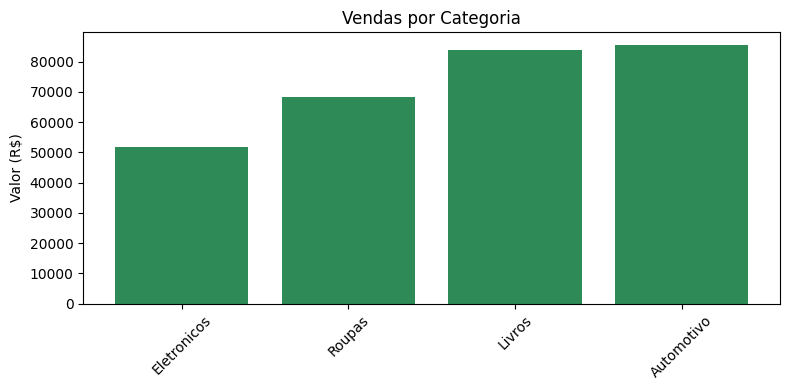

In [9]:
plt.figure(figsize=(8, 4))
plt.bar(vendas_categoria.index, vendas_categoria.values, color='seagreen')
plt.title('Vendas por Categoria')
plt.ylabel('Valor (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### `plt.hist()` — Histograma

Distribui os dados em intervalos (bins) mostrando a **frequência** dos valores.

**Sintaxe:** `plt.hist(dados, bins=n, edgecolor=cor)`

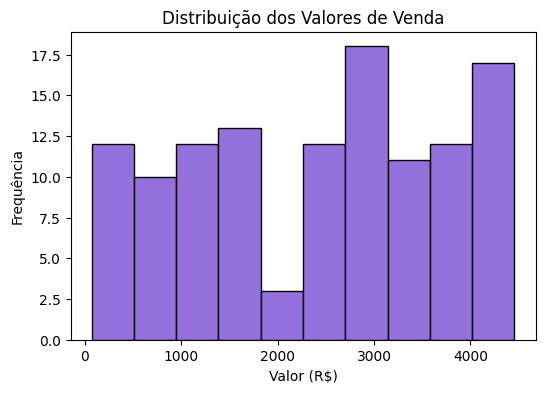

In [10]:
plt.figure(figsize=(6, 4))
plt.hist(df['valor'], bins=10, edgecolor='black', color='mediumpurple')
plt.title('Distribuição dos Valores de Venda')
plt.xlabel('Valor (R$)')
plt.ylabel('Frequência')
plt.show()

# MÓDULO 2 — Nível Intermediário
## Figuras, Eixos, Estilos e Integração com Pandas

---
## 2.1 API Orientada a Objetos (Figuras e Eixos)

### Tarefa 4: `plt.subplots()` — Múltiplos Gráficos (Subplots em Grade)

Cria uma figura com uma grade 2 x 1 de subplots com o eixo X compartilhado:
- **ax1 (Superior):** Gráfico de linha com o faturamento mensal.
- **ax2 (Inferior):** Gráfico de barras com a quantidade total de itens vendidos no mesmo período.

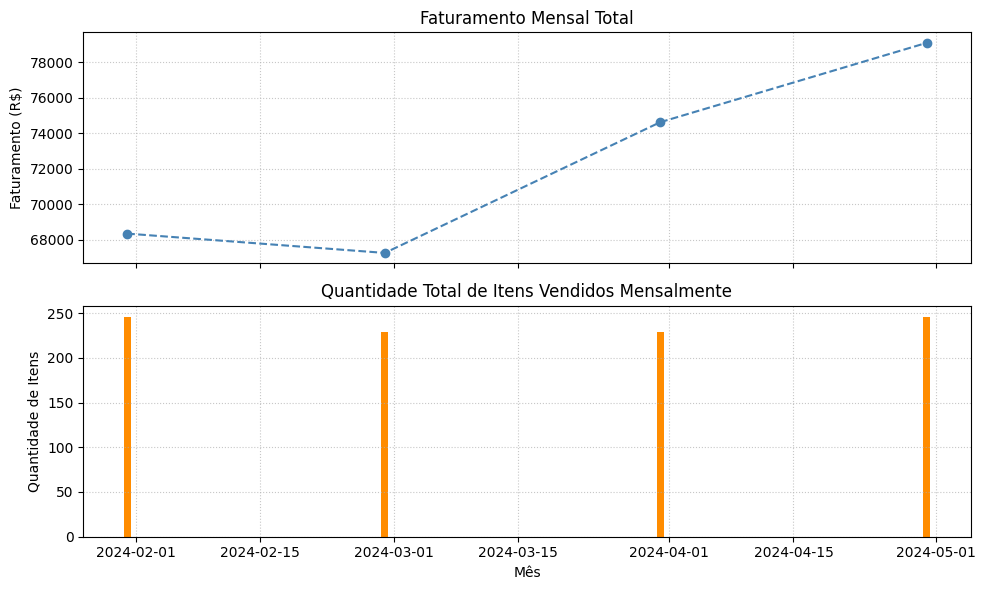

In [11]:
mensal_agg = df.set_index('data').resample('ME').agg({'valor': 'sum', 'quantidade': 'sum'})

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)

ax1.plot(mensal_agg.index, mensal_agg['valor'], marker='o', linestyle='--', color='steelblue')
ax1.set_title('Faturamento Mensal Total')
ax1.set_ylabel('Faturamento (R$)')
ax1.grid(True, linestyle=':', alpha=0.7)

ax2.bar(mensal_agg.index, mensal_agg['quantidade'], color='darkorange')
ax2.set_title('Quantidade Total de Itens Vendidos Mensalmente')
ax2.set_xlabel('Mês')
ax2.set_ylabel('Quantidade de Itens')
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### Tarefa 5: `ax.twinx()` — Dois Eixos Y

- No eixo primário (à esquerda), exiba o valor total vendido por mês em barras.
- No eixo secundário (à direita), plote a quantidade média de itens por venda em linha com marcadores.

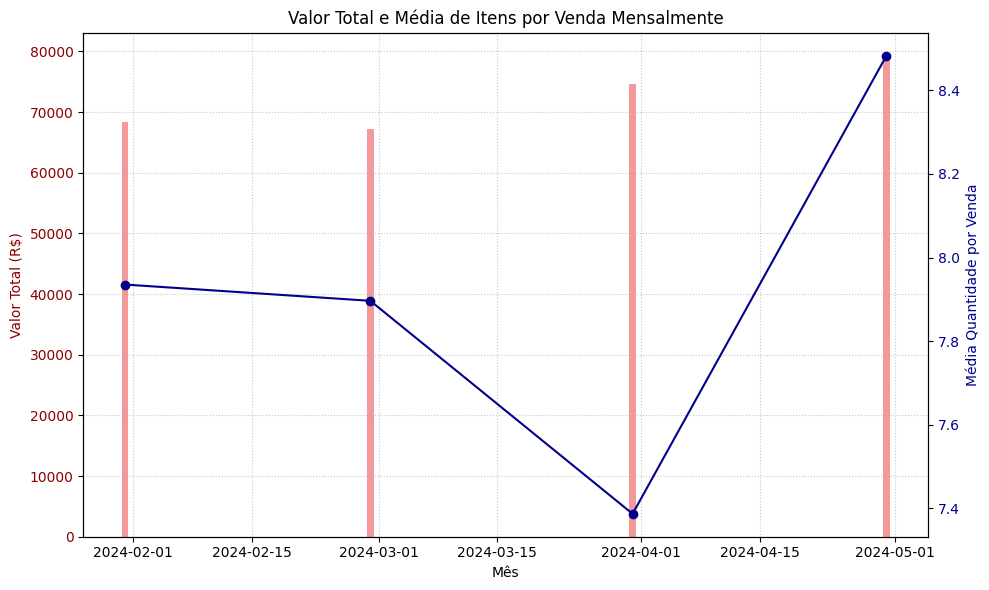

In [5]:
mensal = df.set_index('data')
mensal_total_valor = mensal.resample('ME')['valor'].sum()
mensal_total_quantidade = mensal.resample('ME')['quantidade'].sum()
mensal_numero_vendas = mensal.resample('ME').size()

mensal_media_quantidade_por_venda = mensal_total_quantidade / mensal_numero_vendas

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eixo Y primário (esquerda) - Valor Total Vendido por Mês em barras
ax1.bar(mensal_total_valor.index, mensal_total_valor.values, color='lightcoral', alpha=0.8, label='Valor Total (R$)')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Valor Total (R$)', color='darkred')
ax1.tick_params(axis='y', labelcolor='darkred')
ax1.grid(True, linestyle=':', alpha=0.7)

# Eixo Y secundário (direita) - Quantidade Média de Itens por Venda em linha com marcadores
ax2 = ax1.twinx()
ax2.plot(mensal_media_quantidade_por_venda.index, mensal_media_quantidade_por_venda.values, color='darkblue', marker='o', linestyle='-', label='Média Qtd. por Venda')
ax2.set_ylabel('Média Quantidade por Venda', color='darkblue')
ax2.tick_params(axis='y', labelcolor='darkblue')

plt.title('Valor Total e Média de Itens por Venda Mensalmente')
fig.tight_layout()
plt.show()

### Tarefa 6: Anotação de Pico de Faturamento

No gráfico de linha mensal, identifique o mês de maior faturamento e adicione uma anotação com seta apontando para o pico usando `ax.annotate()`.

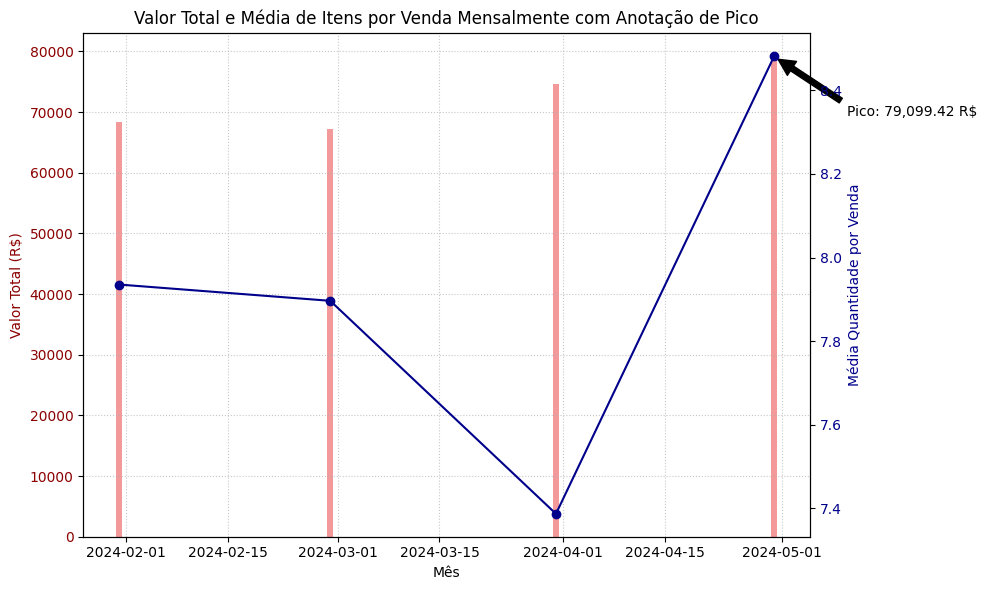

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Eixo Y primário (esquerda) - Valor Total Vendido por Mês em barras
ax1.bar(mensal_total_valor.index, mensal_total_valor.values, color='lightcoral', alpha=0.8, label='Valor Total (R$)')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Valor Total (R$)', color='darkred')
ax1.tick_params(axis='y', labelcolor='darkred')
ax1.grid(True, linestyle=':', alpha=0.7)

# Eixo Y secundário (direita) - Quantidade Média de Itens por Venda em linha com marcadores
ax2 = ax1.twinx()
ax2.plot(mensal_media_quantidade_por_venda.index, mensal_media_quantidade_por_venda.values, color='darkblue', marker='o', linestyle='-', label='Média Qtd. por Venda')
ax2.set_ylabel('Média Quantidade por Venda', color='darkblue')
ax2.tick_params(axis='y', labelcolor='darkblue')

# Anotação para o pico de faturamento (usando mensal_total_valor)
pico_valor_mes = mensal_total_valor.idxmax()
pico_valor = mensal_total_valor.max()

ax1.annotate(f'Pico: {pico_valor:,.2f} R$',
             xy=(pico_valor_mes, pico_valor),
             xytext=(pico_valor_mes + pd.DateOffset(days=10), pico_valor * 0.9),
             arrowprops=dict(facecolor='black', shrink=0.05),
             horizontalalignment='left',
             verticalalignment='top',
             fontsize=10,
             color='black')

plt.title('Valor Total e Média de Itens por Venda Mensalmente com Anotação de Pico')
fig.tight_layout()
plt.show()

# MÓDULO 3 — Nível Avançado
## Layouts Complexos, Heatmaps, 3D e Configuração Global

---
## 3.2 Heatmaps e `imshow`

### Tarefa 7: `pd.pivot_table()` — Matriz de Intensidade

Construa uma tabela dinâmica (`pd.pivot_table`) somando os valores de venda agrupados por categoria nas linhas e estado nas colunas.

In [12]:
pivot_table_vendas = pd.pivot_table(df, values='valor', index='categoria', columns='estado', aggfunc='sum', fill_value=0)
print("Pivot Table de Vendas:\n", pivot_table_vendas)

Pivot Table de Vendas:
 estado             BA        MG        RJ        RS        SP
categoria                                                    
Automotivo    7514.28  15732.40  26383.20   9863.20  25878.61
Eletronicos  13455.10  13489.07   1197.84  14273.33   9468.10
Livros        4635.93  25664.89  10201.13  18900.98  24478.24
Roupas       27213.86   9417.84  11362.65   4578.10  15631.96


### Tarefa 8: `plt.imshow()` — Renderizar Heatmap

Renderize essa matriz na forma de um Heatmap utilizando `plt.imshow()`, incluindo uma barra de cores (`plt.colorbar()`) e os respectivos rótulos nominais nas marcações dos eixos X (`xticks`) e Y (`yticks`).

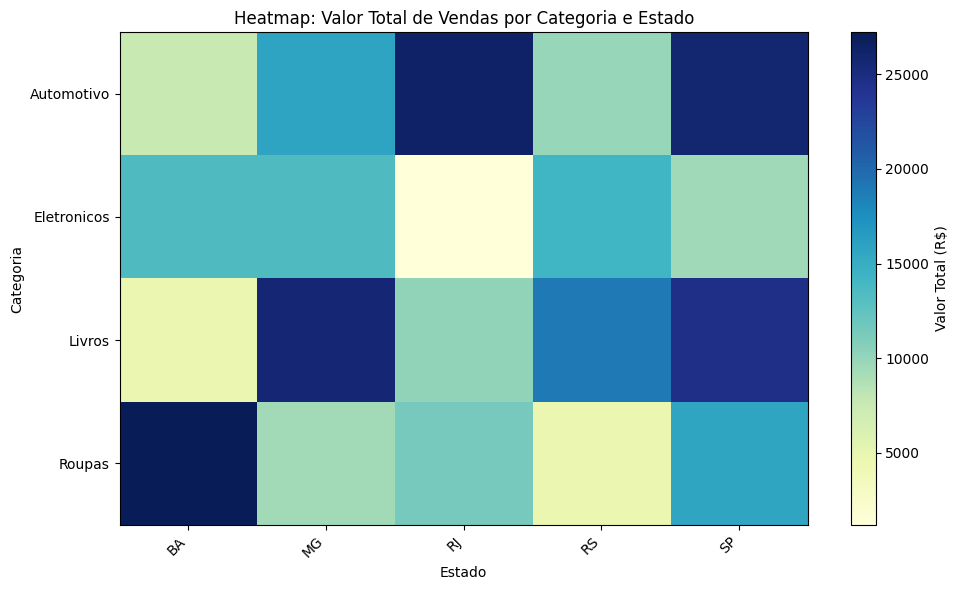

In [13]:
plt.figure(figsize=(10, 6))
plt.imshow(pivot_table_vendas.values, cmap='YlGnBu', aspect='auto')
plt.colorbar(label='Valor Total (R$)')
plt.xticks(range(len(pivot_table_vendas.columns)), pivot_table_vendas.columns, rotation=45, ha='right')
plt.yticks(range(len(pivot_table_vendas.index)), pivot_table_vendas.index)
plt.title('Heatmap: Valor Total de Vendas por Categoria e Estado')
plt.xlabel('Estado')
plt.ylabel('Categoria')
plt.tight_layout()
plt.show()

### Tarefa 9: `plt.savefig()` — Salvar Heatmap em Arquivo

Salve a figura gerada no passo 8 em um arquivo de imagem 'heatmap_vendas.png' com resolução de 300 DPI e corte ajustado (`bbox_inches='tight'`).

Heatmap salvo como heatmap_vendas.png


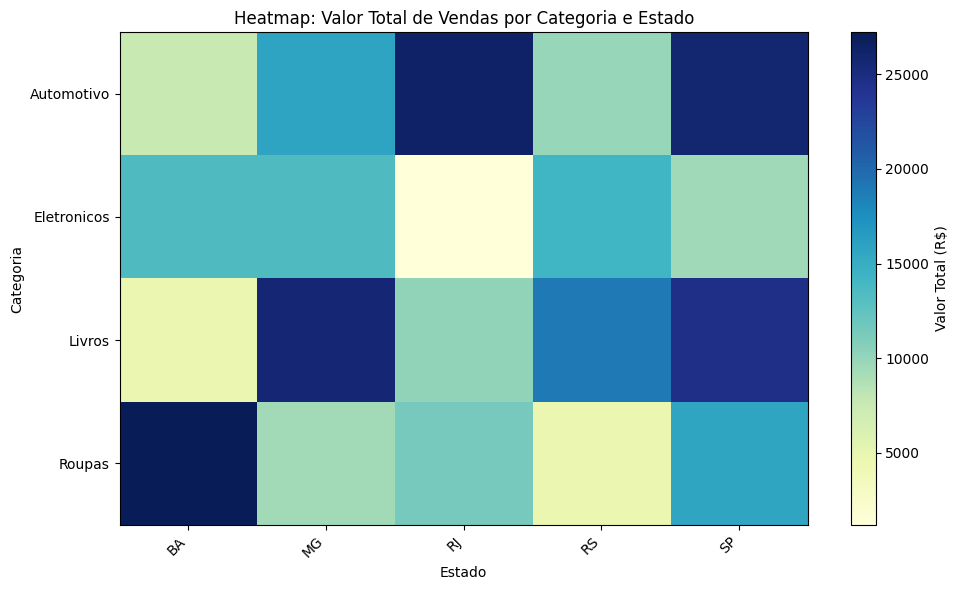

In [14]:
plt.figure(figsize=(10, 6))
plt.imshow(pivot_table_vendas.values, cmap='YlGnBu', aspect='auto')
plt.colorbar(label='Valor Total (R$)')
plt.xticks(range(len(pivot_table_vendas.columns)), pivot_table_vendas.columns, rotation=45, ha='right')
plt.yticks(range(len(pivot_table_vendas.index)), pivot_table_vendas.index)
plt.title('Heatmap: Valor Total de Vendas por Categoria e Estado')
plt.xlabel('Estado')
plt.ylabel('Categoria')
plt.tight_layout()
plt.savefig('heatmap_vendas.png', dpi=300, bbox_inches='tight')
print('Heatmap salvo como heatmap_vendas.png')